# A10 Text Analytics: FDA Recall Severity Classification


# Imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Load the Data

In [2]:
# Load the recall data
# If you are using Colab, upload FoodRecalls.xlsx to the working directory first.
df = pd.read_excel('data/FoodRecalls.xlsx')

print(df.shape)
df.head()

(99729, 17)


,FEI Number,Recalling Firm Name,Product Type,Product Classification,Status,Distribution Pattern,Recalling Firm City,Recalling Firm State,Recalling Firm Country,Center Classification Date,Reason for Recall,Product Description,Event ID,Event Classification,Product ID,Center,Recall Details
0,1626009,Oklahoma Blood Institute,Biologics,Class II,Terminated,Oklahoma,Oklahoma City,Oklahoma,United States,2025-12-12,"Leukoreduced Red Blood Cells, mislabeled for t...","Red Blood Cells, Leukocytes Reduced",98054,Class II,217504,CBER,https://www.accessdata.fda.gov/scripts/ires/?P...
1,1417592,"Medline Industries, LP",Devices,Class II,Ongoing,"US Nationwide distribution in the states CA, C...",Northfield,Illinois,United States,2025-12-12,The items may have weak packaging seals that m...,"SCISSORS, OR, SHARP/BLUNT, 5.5"", STERILE, Item...",98066,Class II,217548,CDRH,https://www.accessdata.fda.gov/scripts/ires/?P...
2,1417592,"Medline Industries, LP",Devices,Class II,Ongoing,"US Nationwide distribution in the states CA, C...",Northfield,Illinois,United States,2025-12-12,The items may have weak packaging seals that m...,"FORCEP, STD STR, STERILE KELLY, 5.5 IN, Item N...",98066,Class II,217549,CDRH,https://www.accessdata.fda.gov/scripts/ires/?P...
3,2221819,"Mindray DS USA, Inc. dba Mindray North America",Devices,Class II,Ongoing,Worldwide distribution - US Nationwide and the...,Mahwah,New Jersey,United States,2025-12-12,When the Worstation of the BeneVision DMS has ...,Hardware configuration of the BeneVision Centr...,97969,Class II,217345,CDRH,https://www.accessdata.fda.gov/scripts/ires/?P...
4,3002807757,"Novocol Pharmaceutical of Canada, Inc.",Drugs,Class II,Ongoing,U.S.A. Nationwide,Cambridge,-,Canada,2025-12-12,Defective container: cracked/broken cartridges,"2% Xylocaine DENTAL with Epinephrine 1:100,000...",98080,Class II,217585,CDER,https://www.accessdata.fda.gov/scripts/ires/?P...


# Basic Data Checks

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99729 entries, 0 to 99728
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   FEI Number                  99729 non-null  object        
 1   Recalling Firm Name         99729 non-null  object        
 2   Product Type                99729 non-null  object        
 3   Product Classification      99729 non-null  object        
 4   Status                      99729 non-null  object        
 5   Distribution Pattern        99727 non-null  object        
 6   Recalling Firm City         99729 non-null  object        
 7   Recalling Firm State        99729 non-null  object        
 8   Recalling Firm Country      99729 non-null  object        
 9   Center Classification Date  99729 non-null  datetime64[ns]
 10  Reason for Recall           99729 non-null  object        
 11  Product Description         99729 non-null  object    

In [4]:
df.isna().sum()

FEI Number                    0
Recalling Firm Name           0
Product Type                  0
Product Classification        0
Status                        0
Distribution Pattern          2
Recalling Firm City           0
Recalling Firm State          0
Recalling Firm Country        0
Center Classification Date    0
Reason for Recall             0
Product Description           0
Event ID                      0
Event Classification          0
Product ID                    0
Center                        0
Recall Details                0
dtype: int64

# Traditional EDA on the Recall Data

In this dataset, the target variable is **Event Classification**.


In [5]:
# Check the target variable
classification_counts = df['Event Classification'].value_counts()
classification_counts

Event Classification
Class II     70530
Class I      21232
Class III     7967
Name: count, dtype: int64

In [6]:
# Check percentages for imbalance
classification_pct = df['Event Classification'].value_counts(normalize=True)
classification_pct

Event Classification
Class II     0.707217
Class I      0.212897
Class III    0.079886
Name: proportion, dtype: float64

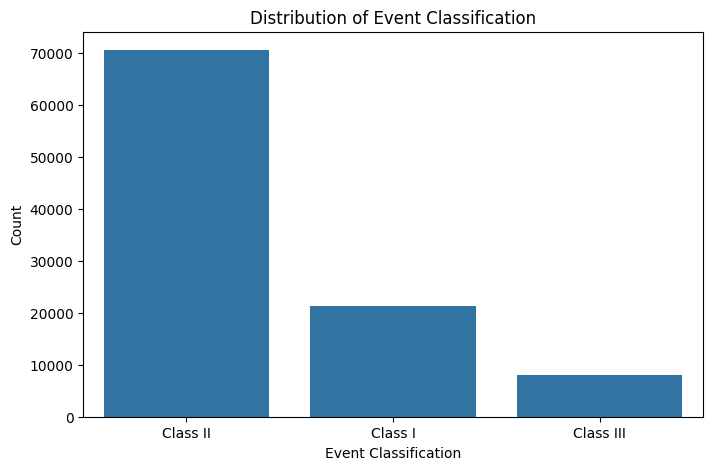

In [7]:
# Plot the imbalance
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Event Classification')
plt.title('Distribution of Event Classification')
plt.xlabel('Event Classification')
plt.ylabel('Count')
plt.show()

**Figure 1:** TARGET IMBALANCE! 


### Text Length Check



In [8]:
# Create the same text field early so we can check text length
eda_text = (
    df['Product Description'].fillna('').astype(str) + ' ' +
    df['Reason for Recall'].fillna('').astype(str)
)

eda_text_length = eda_text.str.len()

eda_text_length.describe()

count    99729.000000
mean       359.389776
std        353.094830
min          8.000000
25%        170.000000
50%        281.000000
75%        426.000000
max      11318.000000
dtype: float64

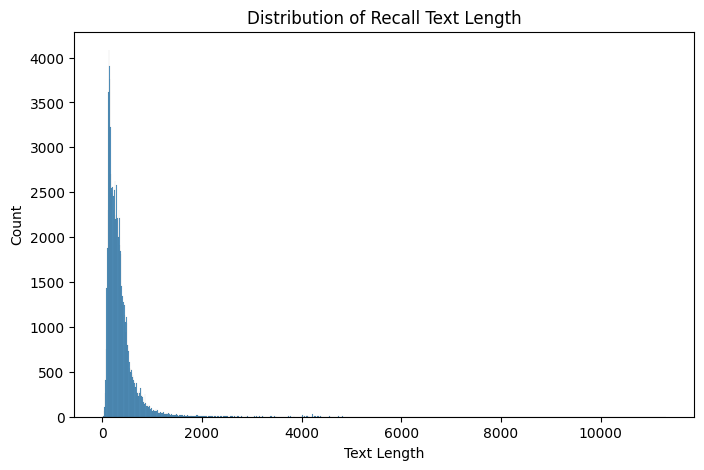

In [9]:
# Plot the distribution of text length
plt.figure(figsize=(8, 5))
sns.histplot(eda_text_length)
plt.title('Distribution of Recall Text Length')
plt.xlabel('Text Length')
plt.ylabel('Count')
plt.show()

**Figure 2:** Distribution of the concatenated text length from Product Description and Reason for Recall.

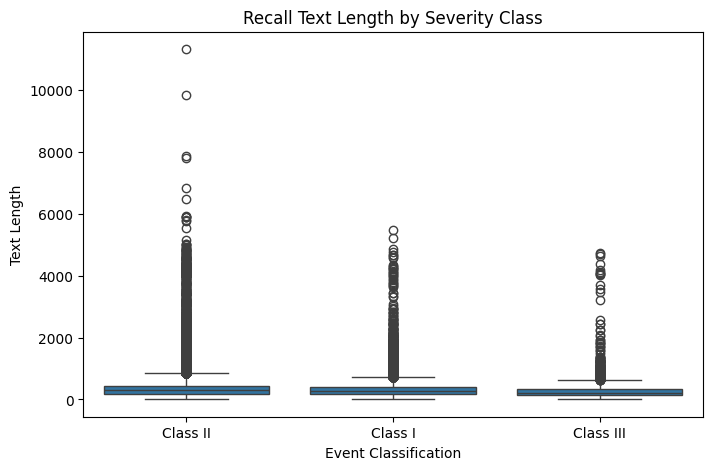

In [10]:
# create temporary dataframe for EDA
eda_df = pd.DataFrame({
    'Event Classification': df['Event Classification'],
    'text_length': eda_text_length
})
eda_df.groupby('Event Classification')['text_length'].mean()
plt.figure(figsize=(8,5))

sns.boxplot(
    data=eda_df,
    x='Event Classification',
    y='text_length'
)

plt.title('Recall Text Length by Severity Class')

plt.xlabel('Event Classification')

plt.ylabel('Text Length')

plt.show()

**Figure 3:** Distribution of the concatenated text length GROUP BY TARGET -EVENT CLASSIFICATION

# Dig into the Recall Text

We will build text classification models using the two columns named in the assignment:

- **Product Description**
- **Reason for Recall**

Following the lecture-note workflow, we create one text column and then clean it.


In [11]:
# Keep only the columns needed for this assignment
recall_df = df[[
    'Product Description',
    'Reason for Recall',
    'Event Classification'
]].copy()

print('Original shape:', recall_df.shape)

# Drop rows where the target is missing
recall_df = recall_df.dropna(subset=['Event Classification'])

# Create one text column using both assignment text fields
recall_df['RECALL_TEXT'] = (
    recall_df['Product Description'].fillna('').astype(str) + ' ' +
    recall_df['Reason for Recall'].fillna('').astype(str)
)

# Strip blank text rows, because both text columns are needed for modeling
recall_df['RECALL_TEXT'] = recall_df['RECALL_TEXT'].str.strip()
recall_df = recall_df[recall_df['RECALL_TEXT'] != '']

# Drop duplicate descriptions / reasons after creating the concatenated text field
recall_df = recall_df.drop_duplicates(subset=['RECALL_TEXT'])

print('After missing/dirty row handling and duplicate text removal:', recall_df.shape)
recall_df.head()

Original shape: (99729, 3)
After missing/dirty row handling and duplicate text removal: (93936, 4)


,Product Description,Reason for Recall,Event Classification,RECALL_TEXT
0,"Red Blood Cells, Leukocytes Reduced","Leukoreduced Red Blood Cells, mislabeled for t...",Class II,"Red Blood Cells, Leukocytes Reduced Leukoreduc..."
1,"SCISSORS, OR, SHARP/BLUNT, 5.5"", STERILE, Item...",The items may have weak packaging seals that m...,Class II,"SCISSORS, OR, SHARP/BLUNT, 5.5"", STERILE, Item..."
2,"FORCEP, STD STR, STERILE KELLY, 5.5 IN, Item N...",The items may have weak packaging seals that m...,Class II,"FORCEP, STD STR, STERILE KELLY, 5.5 IN, Item N..."
3,Hardware configuration of the BeneVision Centr...,When the Worstation of the BeneVision DMS has ...,Class II,Hardware configuration of the BeneVision Centr...
4,"2% Xylocaine DENTAL with Epinephrine 1:100,000...",Defective container: cracked/broken cartridges,Class II,"2% Xylocaine DENTAL with Epinephrine 1:100,000..."


# Reset the Index

In [12]:
# reset the index just so it looks nice
recall_df.reset_index(inplace=True)
recall_df.head()

,index,Product Description,Reason for Recall,Event Classification,RECALL_TEXT
0,0,"Red Blood Cells, Leukocytes Reduced","Leukoreduced Red Blood Cells, mislabeled for t...",Class II,"Red Blood Cells, Leukocytes Reduced Leukoreduc..."
1,1,"SCISSORS, OR, SHARP/BLUNT, 5.5"", STERILE, Item...",The items may have weak packaging seals that m...,Class II,"SCISSORS, OR, SHARP/BLUNT, 5.5"", STERILE, Item..."
2,2,"FORCEP, STD STR, STERILE KELLY, 5.5 IN, Item N...",The items may have weak packaging seals that m...,Class II,"FORCEP, STD STR, STERILE KELLY, 5.5 IN, Item N..."
3,3,Hardware configuration of the BeneVision Centr...,When the Worstation of the BeneVision DMS has ...,Class II,Hardware configuration of the BeneVision Centr...
4,4,"2% Xylocaine DENTAL with Epinephrine 1:100,000...",Defective container: cracked/broken cartridges,Class II,"2% Xylocaine DENTAL with Epinephrine 1:100,000..."


In [13]:
# get rid of the original index column
del recall_df['index']
print(recall_df.shape)
recall_df.head()

(93936, 4)


,Product Description,Reason for Recall,Event Classification,RECALL_TEXT
0,"Red Blood Cells, Leukocytes Reduced","Leukoreduced Red Blood Cells, mislabeled for t...",Class II,"Red Blood Cells, Leukocytes Reduced Leukoreduc..."
1,"SCISSORS, OR, SHARP/BLUNT, 5.5"", STERILE, Item...",The items may have weak packaging seals that m...,Class II,"SCISSORS, OR, SHARP/BLUNT, 5.5"", STERILE, Item..."
2,"FORCEP, STD STR, STERILE KELLY, 5.5 IN, Item N...",The items may have weak packaging seals that m...,Class II,"FORCEP, STD STR, STERILE KELLY, 5.5 IN, Item N..."
3,Hardware configuration of the BeneVision Centr...,When the Worstation of the BeneVision DMS has ...,Class II,Hardware configuration of the BeneVision Centr...
4,"2% Xylocaine DENTAL with Epinephrine 1:100,000...",Defective container: cracked/broken cartridges,Class II,"2% Xylocaine DENTAL with Epinephrine 1:100,000..."


### Lowercase


In [14]:
# make everything lowercase
recall_df['RECALL_TEXT'] = recall_df['RECALL_TEXT'].str.lower()
recall_df.head()

,Product Description,Reason for Recall,Event Classification,RECALL_TEXT
0,"Red Blood Cells, Leukocytes Reduced","Leukoreduced Red Blood Cells, mislabeled for t...",Class II,"red blood cells, leukocytes reduced leukoreduc..."
1,"SCISSORS, OR, SHARP/BLUNT, 5.5"", STERILE, Item...",The items may have weak packaging seals that m...,Class II,"scissors, or, sharp/blunt, 5.5"", sterile, item..."
2,"FORCEP, STD STR, STERILE KELLY, 5.5 IN, Item N...",The items may have weak packaging seals that m...,Class II,"forcep, std str, sterile kelly, 5.5 in, item n..."
3,Hardware configuration of the BeneVision Centr...,When the Worstation of the BeneVision DMS has ...,Class II,hardware configuration of the benevision centr...
4,"2% Xylocaine DENTAL with Epinephrine 1:100,000...",Defective container: cracked/broken cartridges,Class II,"2% xylocaine dental with epinephrine 1:100,000..."


In [15]:
# here's an example of what we did
print(recall_df['RECALL_TEXT'][0])
print(recall_df['RECALL_TEXT'][1])
print(recall_df['RECALL_TEXT'][2])

red blood cells, leukocytes reduced leukoreduced red blood cells, mislabeled for the rh(d) antigen, were distributed.
scissors, or, sharp/blunt, 5.5", sterile, item number dynd04000_x000d_
 the items may have weak packaging seals that may result in a breach of sterility if the seal fails and may lead to an increased risk of infection if product is utilized.
forcep, std str, sterile kelly, 5.5 in, item number dynj04048 the items may have weak packaging seals that may result in a breach of sterility if the seal fails and may lead to an increased risk of infection if product is utilized.


### Strip funky characters (!, ~, -, @, $, %, etc.)


In [16]:
recall_df['RECALL_TEXT'] = recall_df['RECALL_TEXT'].str.lower()
recall_df['RECALL_TEXT'] = recall_df['RECALL_TEXT'].str.replace(r'[^a-zA-Z ]','', regex=True).str.replace(r' +',' ', regex=True).str.strip()
recall_df.head()

,Product Description,Reason for Recall,Event Classification,RECALL_TEXT
0,"Red Blood Cells, Leukocytes Reduced","Leukoreduced Red Blood Cells, mislabeled for t...",Class II,red blood cells leukocytes reduced leukoreduce...
1,"SCISSORS, OR, SHARP/BLUNT, 5.5"", STERILE, Item...",The items may have weak packaging seals that m...,Class II,scissors or sharpblunt sterile item number dyn...
2,"FORCEP, STD STR, STERILE KELLY, 5.5 IN, Item N...",The items may have weak packaging seals that m...,Class II,forcep std str sterile kelly in item number dy...
3,Hardware configuration of the BeneVision Centr...,When the Worstation of the BeneVision DMS has ...,Class II,hardware configuration of the benevision centr...
4,"2% Xylocaine DENTAL with Epinephrine 1:100,000...",Defective container: cracked/broken cartridges,Class II,xylocaine dental with epinephrine lidocaine hc...


In [17]:
# let's see what we did, no commas or periods!
print(recall_df['RECALL_TEXT'][0])
print(recall_df['RECALL_TEXT'][1])
print(recall_df['RECALL_TEXT'][2])

red blood cells leukocytes reduced leukoreduced red blood cells mislabeled for the rhd antigen were distributed
scissors or sharpblunt sterile item number dyndxd the items may have weak packaging seals that may result in a breach of sterility if the seal fails and may lead to an increased risk of infection if product is utilized
forcep std str sterile kelly in item number dynj the items may have weak packaging seals that may result in a breach of sterility if the seal fails and may lead to an increased risk of infection if product is utilized


### Stop words



In [18]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
print(stopwords.words('english'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

[nltk_data] Downloading package stopwords to /Users/nayeong-
[nltk_data]     eun/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [19]:
stop = stopwords.words('english')

# apply these stopwords to the data
recall_df['RECALL_TEXT'] = recall_df['RECALL_TEXT'].apply(
    lambda x: ' '.join([word for word in x.split() if word not in (stop)])
)

recall_df.head()

,Product Description,Reason for Recall,Event Classification,RECALL_TEXT
0,"Red Blood Cells, Leukocytes Reduced","Leukoreduced Red Blood Cells, mislabeled for t...",Class II,red blood cells leukocytes reduced leukoreduce...
1,"SCISSORS, OR, SHARP/BLUNT, 5.5"", STERILE, Item...",The items may have weak packaging seals that m...,Class II,scissors sharpblunt sterile item number dyndxd...
2,"FORCEP, STD STR, STERILE KELLY, 5.5 IN, Item N...",The items may have weak packaging seals that m...,Class II,forcep std str sterile kelly item number dynj ...
3,Hardware configuration of the BeneVision Centr...,When the Worstation of the BeneVision DMS has ...,Class II,hardware configuration benevision central moni...
4,"2% Xylocaine DENTAL with Epinephrine 1:100,000...",Defective container: cracked/broken cartridges,Class II,xylocaine dental epinephrine lidocaine hci epi...


In [20]:
# let's see what we did
print(recall_df['RECALL_TEXT'][0])
print(recall_df['RECALL_TEXT'][1])
print(recall_df['RECALL_TEXT'][2])

red blood cells leukocytes reduced leukoreduced red blood cells mislabeled rhd antigen distributed
scissors sharpblunt sterile item number dyndxd items may weak packaging seals may result breach sterility seal fails may lead increased risk infection product utilized
forcep std str sterile kelly item number dynj items may weak packaging seals may result breach sterility seal fails may lead increased risk infection product utilized


# Text EDA on the Recall Data

### Most common words



In [21]:
# what are the most common words in the recall text?
myTable = recall_df['RECALL_TEXT'].str.split(expand=True).stack().value_counts()
myTable[0:20]

product        31919
may            26892
oz             24293
products       23153
number         22149
ml             19037
upc            17690
system         17146
potential      15585
distributed    15007
use            14920
blood          13689
inc            13568
ndc            13048
xd             12965
mm             12898
due            12828
rx             12289
used           12111
pack           12098
Name: count, dtype: int64

In [22]:
# and we can make a frequency plot
# we'll group, then convert to pandas DataFrame for easy plotting
x = recall_df['RECALL_TEXT'].str.split(expand=True).stack().value_counts()
x = pd.DataFrame(x)

# reset the index
x.reset_index(inplace=True)

# rename the columns
x.rename(columns={x.columns[0]:'word', x.columns[1]:'frequency'}, inplace=True)
x.head()

,word,frequency
0,product,31919
1,may,26892
2,oz,24293
3,products,23153
4,number,22149


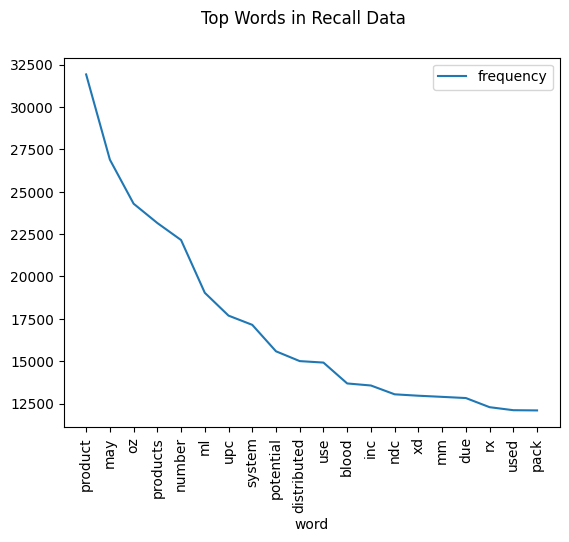

In [23]:
# Frequency Distribution Plot
# look at first X words

x = x[0:20]
x.plot(x='word', y='frequency')
plt.xticks(np.arange(len(x)), x['word'], rotation=90)
plt.suptitle('Top Words in Recall Data')
plt.show()

**Figure 3:** Top words in the FDA recall text.


### Word Cloud

A word cloud gives a quick visual summary of frequent words.


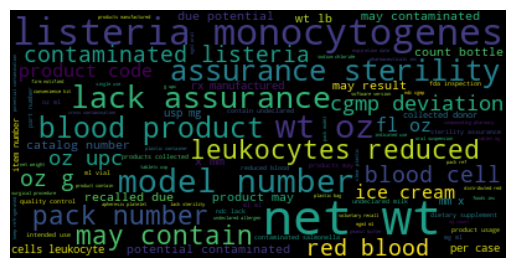

In [24]:
from wordcloud import WordCloud

# Generate a word cloud image
wordcloud = WordCloud(max_font_size=40).generate(' '.join(recall_df['RECALL_TEXT']))

plt.figure()
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

**Figure 4:** Word cloud of top words in the recall text. Size is proportional to frequency.


### Tokenizer

The tokenizer takes a sentence and parses it into a list of individual words.


In [25]:
# tokenizer
nltk.download('punkt')
nltk.download('punkt_tab')

recall_df['RECALL_TEXT'] = recall_df.apply(lambda row: nltk.word_tokenize(row['RECALL_TEXT']), axis=1)
recall_df.head()

[nltk_data] Downloading package punkt to /Users/nayeong-
[nltk_data]     eun/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /Users/nayeong-
[nltk_data]     eun/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,Product Description,Reason for Recall,Event Classification,RECALL_TEXT
0,"Red Blood Cells, Leukocytes Reduced","Leukoreduced Red Blood Cells, mislabeled for t...",Class II,"[red, blood, cells, leukocytes, reduced, leuko..."
1,"SCISSORS, OR, SHARP/BLUNT, 5.5"", STERILE, Item...",The items may have weak packaging seals that m...,Class II,"[scissors, sharpblunt, sterile, item, number, ..."
2,"FORCEP, STD STR, STERILE KELLY, 5.5 IN, Item N...",The items may have weak packaging seals that m...,Class II,"[forcep, std, str, sterile, kelly, item, numbe..."
3,Hardware configuration of the BeneVision Centr...,When the Worstation of the BeneVision DMS has ...,Class II,"[hardware, configuration, benevision, central,..."
4,"2% Xylocaine DENTAL with Epinephrine 1:100,000...",Defective container: cracked/broken cartridges,Class II,"[xylocaine, dental, epinephrine, lidocaine, hc..."


In [26]:
# here's what we did
print(recall_df['RECALL_TEXT'][0])
print(recall_df['RECALL_TEXT'][1])
print(recall_df['RECALL_TEXT'][2])

['red', 'blood', 'cells', 'leukocytes', 'reduced', 'leukoreduced', 'red', 'blood', 'cells', 'mislabeled', 'rhd', 'antigen', 'distributed']
['scissors', 'sharpblunt', 'sterile', 'item', 'number', 'dyndxd', 'items', 'may', 'weak', 'packaging', 'seals', 'may', 'result', 'breach', 'sterility', 'seal', 'fails', 'may', 'lead', 'increased', 'risk', 'infection', 'product', 'utilized']
['forcep', 'std', 'str', 'sterile', 'kelly', 'item', 'number', 'dynj', 'items', 'may', 'weak', 'packaging', 'seals', 'may', 'result', 'breach', 'sterility', 'seal', 'fails', 'may', 'lead', 'increased', 'risk', 'infection', 'product', 'utilized']


# Lexicon Normalization

### Stemming



In [27]:
recall_df['RECALL_TEXT'] = recall_df['RECALL_TEXT'].astype(str)

In [28]:

from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

ps = PorterStemmer()

filtered_sent = recall_df['RECALL_TEXT'][0]

# tokenize first
token_words = word_tokenize(filtered_sent)

stemmed_words = []

for w in token_words:
    stemmed_words.append(ps.stem(w))

print('Filtered Sentence:', filtered_sent)
print('Stemmed Sentence:', stemmed_words)

Filtered Sentence: ['red', 'blood', 'cells', 'leukocytes', 'reduced', 'leukoreduced', 'red', 'blood', 'cells', 'mislabeled', 'rhd', 'antigen', 'distributed']
Stemmed Sentence: ['[', "'red", "'", ',', "'blood", "'", ',', "'cell", "'", ',', "'leukocyt", "'", ',', "'reduc", "'", ',', "'leukoreduc", "'", ',', "'red", "'", ',', "'blood", "'", ',', "'cell", "'", ',', "'mislabel", "'", ',', "'rhd", "'", ',', "'antigen", "'", ',', "'distribut", "'", ']']


In [29]:
from nltk.tokenize import word_tokenize

# create a new column with stemmed words
recall_df['Stemmed'] = recall_df['RECALL_TEXT'].apply(
    lambda x: [ps.stem(y) for y in word_tokenize(x)]
)

# check your work!
print(recall_df['RECALL_TEXT'][0])
print(recall_df['Stemmed'][0])

['red', 'blood', 'cells', 'leukocytes', 'reduced', 'leukoreduced', 'red', 'blood', 'cells', 'mislabeled', 'rhd', 'antigen', 'distributed']
['[', "'red", "'", ',', "'blood", "'", ',', "'cell", "'", ',', "'leukocyt", "'", ',', "'reduc", "'", ',', "'leukoreduc", "'", ',', "'red", "'", ',', "'blood", "'", ',', "'cell", "'", ',', "'mislabel", "'", ',', "'rhd", "'", ',', "'antigen", "'", ',', "'distribut", "'", ']']


# Making a Text Classification Algorithm

Following the lecture note, we will:

- Clean up the stemmed column into something usable for modeling
- Choose X and Y
- Build Bag of Words or TF-IDF features
- Split the data into train/test partitions
- Fit a classification model
- Check out the error metrics


### Clean up the stemmed column into something useable for modeling

The stemmed column is currently a list. We rejoin the list into a regular cleaned text column.


In [30]:
# here's what it looked like before
recall_df['Stemmed'].head()

0    [[, 'red, ', ,, 'blood, ', ,, 'cell, ', ,, 'le...
1    [[, 'scissor, ', ,, 'sharpblunt, ', ,, 'steril...
2    [[, 'forcep, ', ,, 'std, ', ,, 'str, ', ,, 'st...
3    [[, 'hardwar, ', ,, 'configur, ', ,, 'benevis,...
4    [[, 'xylocain, ', ,, 'dental, ', ,, 'epinephri...
Name: Stemmed, dtype: object

In [31]:
def rejoin_words(row):
    my_list = row['Stemmed']
    joined_words = (" ".join(my_list))
    return joined_words

recall_df['Stemmed'] = recall_df.apply(rejoin_words, axis=1)

print(recall_df['Stemmed'][0])

[ 'red ' , 'blood ' , 'cell ' , 'leukocyt ' , 'reduc ' , 'leukoreduc ' , 'red ' , 'blood ' , 'cell ' , 'mislabel ' , 'rhd ' , 'antigen ' , 'distribut ' ]


### Choose X and Y

We use `Stemmed` as the text feature and `Event Classification` as the target variable.


In [32]:
# split into X and Y
X = pd.DataFrame(recall_df['Stemmed'])
y = recall_df['Event Classification']

print(X.shape, y.shape)
X.head()

(93936, 1) (93936,)


,Stemmed
0,"[ 'red ' , 'blood ' , 'cell ' , 'leukocyt ' , ..."
1,"[ 'scissor ' , 'sharpblunt ' , 'steril ' , 'it..."
2,"[ 'forcep ' , 'std ' , 'str ' , 'steril ' , 'k..."
3,"[ 'hardwar ' , 'configur ' , 'benevis ' , 'cen..."
4,"[ 'xylocain ' , 'dental ' , 'epinephrin ' , 'l..."


# Prepare Text Sequences for Modeling

The rubric also asks for a second data preparation approach for text sequences. This does not change the lecture-note Bag of Words / TF-IDF model below; it simply prepares tokenized, padded, and truncated text sequences for sequence-based models.

In [33]:
# Prepare the data for text sequences
# This section is intentionally simple: tokenize, pad, and truncate.

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

sequence_X_train_text, sequence_X_test_text, sequence_y_train, sequence_y_test = train_test_split(
    X['Stemmed'],
    y,
    test_size=0.1,
    random_state=42,
    stratify=y
)

tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(sequence_X_train_text)

train_sequences = tokenizer.texts_to_sequences(sequence_X_train_text)
test_sequences = tokenizer.texts_to_sequences(sequence_X_test_text)

max_sequence_length = 100

X_train_seq = pad_sequences(
    train_sequences,
    maxlen=max_sequence_length,
    padding='post',
    truncating='post'
)

X_test_seq = pad_sequences(
    test_sequences,
    maxlen=max_sequence_length,
    padding='post',
    truncating='post'
)

print('Train sequence matrix:', X_train_seq.shape)
print('Test sequence matrix: ', X_test_seq.shape)

Train sequence matrix: (84542, 100)
Test sequence matrix:  (9394, 100)


# Naive Majority-Class Baseline

The prompt asks whether the model can beat a naive majority-class model. This checks the baseline accuracy from always predicting the most common class.


In [34]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score

X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X['Stemmed'],
    y,
    test_size=0.1,
    random_state=42,
    stratify=y
)

baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train_base.to_frame(), y_train_base)

baseline_train_pred = baseline.predict(X_train_base.to_frame())
baseline_test_pred = baseline.predict(X_test_base.to_frame())

print('Naive Majority Baseline Train Accuracy:', metrics.accuracy_score(y_train_base, baseline_train_pred))
print('Naive Majority Baseline Test Accuracy:', metrics.accuracy_score(y_test_base, baseline_test_pred))

print('Naive Majority Baseline Test Weighted F1:', f1_score(y_test_base, baseline_test_pred, average='weighted'))

Naive Majority Baseline Train Accuracy: 0.7035792860353434
Naive Majority Baseline Test Accuracy: 0.7035341707472855
Naive Majority Baseline Test Weighted F1: 0.5810982108940586


In [35]:
# Baseline classification report - train
print(classification_report(y_train_base, baseline_train_pred))

              precision    recall  f1-score   support

     Class I       0.00      0.00      0.00     18989
    Class II       0.70      1.00      0.83     59482
   Class III       0.00      0.00      0.00      6071

    accuracy                           0.70     84542
   macro avg       0.23      0.33      0.28     84542
weighted avg       0.50      0.70      0.58     84542



In [36]:
# Baseline confusion matrix - train
confusion_matrix(y_train_base, baseline_train_pred)

array([[    0, 18989,     0],
       [    0, 59482,     0],
       [    0,  6071,     0]])

In [37]:
# Baseline classification report - test
print(classification_report(y_test_base, baseline_test_pred))

              precision    recall  f1-score   support

     Class I       0.00      0.00      0.00      2110
    Class II       0.70      1.00      0.83      6609
   Class III       0.00      0.00      0.00       675

    accuracy                           0.70      9394
   macro avg       0.23      0.33      0.28      9394
weighted avg       0.49      0.70      0.58      9394



In [38]:
# Baseline confusion matrix - test
confusion_matrix(y_test_base, baseline_test_pred)

array([[   0, 2110,    0],
       [   0, 6609,    0],
       [   0,  675,    0]])

# Bag of Words



In [39]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from nltk.tokenize import RegexpTokenizer

# ---------------------------------------
# 1. Start from raw text + labels
# ---------------------------------------
X_text = X['Stemmed']   # your stemmed text column
y_vec  = y              # your target vector

# ---------------------------------------
# 2. Split TEXT first: 90% train, 10% test
# ---------------------------------------
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y_vec,
    test_size=0.1,
    random_state=42,
    stratify=y_vec
)

print('Train:', len(X_train_text), 'Test:', len(X_test_text))

# ---------------------------------------
# 3. Build CountVectorizer and FIT ONLY ON TRAIN
# ---------------------------------------
token = RegexpTokenizer(r'[a-zA-Z0-9]+')

cv = CountVectorizer(
    lowercase=True,
    stop_words='english',
    ngram_range=(1, 1),
    tokenizer=token.tokenize
)

X_train_counts = cv.fit_transform(X_train_text)
X_test_counts  = cv.transform(X_test_text)

print('Train matrix:', X_train_counts.shape)
print('Test matrix: ', X_test_counts.shape)

Train: 84542 Test: 9394
Train matrix: (84542, 95765)
Test matrix:  (9394, 95765)


In [40]:
X_train_counts

<84542x95765 sparse matrix of type '<class 'numpy.int64'>'
	with 2192694 stored elements in Compressed Sparse Row format>

In [41]:
dense_text_counts = X_train_counts.toarray()
print(dense_text_counts[0])
print(np.sum(dense_text_counts[0]))

[0 0 0 ... 0 0 0]
46


### Bag of Words Model

In [42]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
from sklearn.metrics import f1_score

# Model Generation Using Decision Tree Classifier
clf_counts = DecisionTreeClassifier(min_samples_leaf=5, random_state=42, class_weight='balanced').fit(X_train_counts, y_train)

predicted_counts_train = clf_counts.predict(X_train_counts)
predicted_counts = clf_counts.predict(X_test_counts)

print('DTC Train Accuracy:', metrics.accuracy_score(y_train, predicted_counts_train))
print('DTC Test Accuracy:', metrics.accuracy_score(y_test, predicted_counts))
print('DTC Test Weighted F1:', f1_score(y_test, predicted_counts, average='weighted'))

DTC Train Accuracy: 0.9075843959215538
DTC Test Accuracy: 0.8599105812220567
DTC Test Weighted F1: 0.872091652665195


In [43]:
# classification report - train
from sklearn.metrics import classification_report

print(classification_report(y_train, predicted_counts_train))

              precision    recall  f1-score   support

     Class I       0.89      0.96      0.92     18989
    Class II       0.99      0.88      0.93     59482
   Class III       0.54      0.99      0.70      6071

    accuracy                           0.91     84542
   macro avg       0.81      0.94      0.85     84542
weighted avg       0.94      0.91      0.91     84542



In [44]:
# confusion matrix - train
from sklearn.metrics import confusion_matrix

confusion_matrix(y_train, predicted_counts_train)

array([[18210,   401,   378],
       [ 2155, 52487,  4840],
       [   26,    13,  6032]])

In [45]:
# classification report - test
print(classification_report(y_test, predicted_counts))

              precision    recall  f1-score   support

     Class I       0.85      0.90      0.88      2110
    Class II       0.96      0.85      0.90      6609
   Class III       0.42      0.82      0.56       675

    accuracy                           0.86      9394
   macro avg       0.75      0.86      0.78      9394
weighted avg       0.90      0.86      0.87      9394



In [46]:
# confusion matrix - test
confusion_matrix(y_test, predicted_counts)

array([[1902,  121,   87],
       [ 306, 5620,  683],
       [  18,  101,  556]])

# TF-IDF



In [47]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.tokenize import RegexpTokenizer

# ---------------------------------------
# 1. Start from raw text + labels
# ---------------------------------------
X_text = X['Stemmed']
y_vec  = y

# ---------------------------------------
# 2. Split TEXT first: 90% train, 10% test
# ---------------------------------------
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y_vec,
    test_size=0.1,
    random_state=42,
    stratify=y_vec
)

print('Train:', len(X_train_text), 'Test:', len(X_test_text))

# ---------------------------------------
# 3. Build TF-IDF vectorizer and FIT ONLY ON TRAIN
# ---------------------------------------
token = RegexpTokenizer(r'[a-zA-Z0-9]+')

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    ngram_range=(1, 1),
    tokenizer=token.tokenize
)

X_train_tf = tfidf.fit_transform(X_train_text)
X_test_tf  = tfidf.transform(X_test_text)

print('Train TF-IDF matrix:', X_train_tf.shape)
print('Test TF-IDF matrix: ', X_test_tf.shape)

Train: 84542 Test: 9394
Train TF-IDF matrix: (84542, 95765)
Test TF-IDF matrix:  (9394, 95765)


In [48]:
#X_train_tf

In [49]:
#dense_text_counts = X_train_tf.toarray()
#print(dense_text_counts[0])

### TF-IDF Model

In [50]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
from sklearn.metrics import f1_score

# Model Generation Using Decision Tree Classifier
clf_tfidf = DecisionTreeClassifier(min_samples_leaf=5,  class_weight='balanced', random_state=42).fit(X_train_tf, y_train)

predicted_tfidf_train = clf_tfidf.predict(X_train_tf)
predicted_tfidf = clf_tfidf.predict(X_test_tf)

print('DTC Train Accuracy:', metrics.accuracy_score(y_train, predicted_tfidf_train))
print('DTC Test Accuracy:', metrics.accuracy_score(y_test, predicted_tfidf))
print('DTC Test Weighted F1:', f1_score(y_test, predicted_tfidf, average='weighted'))

DTC Train Accuracy: 0.9237065600529915
DTC Test Accuracy: 0.8588460719608261
DTC Test Weighted F1: 0.8691018949712289


In [51]:
# classification report - train
from sklearn.metrics import classification_report

print(classification_report(y_train, predicted_tfidf_train))

              precision    recall  f1-score   support

     Class I       0.90      0.96      0.93     18989
    Class II       0.99      0.90      0.95     59482
   Class III       0.59      1.00      0.74      6071

    accuracy                           0.92     84542
   macro avg       0.83      0.95      0.87     84542
weighted avg       0.94      0.92      0.93     84542



In [52]:
# confusion matrix - train
from sklearn.metrics import confusion_matrix

confusion_matrix(y_train, predicted_tfidf_train)

array([[18294,   343,   352],
       [ 1953, 53754,  3775],
       [   19,     8,  6044]])

In [53]:
# classification report - test
print(classification_report(y_test, predicted_tfidf))

              precision    recall  f1-score   support

     Class I       0.85      0.89      0.87      2110
    Class II       0.95      0.86      0.90      6609
   Class III       0.43      0.79      0.56       675

    accuracy                           0.86      9394
   macro avg       0.74      0.85      0.78      9394
weighted avg       0.89      0.86      0.87      9394



In [54]:
# confusion matrix - test
confusion_matrix(y_test, predicted_tfidf)

array([[1882,  173,   55],
       [ 313, 5654,  642],
       [  23,  120,  532]])

# xAI

To reduce runtime and memory usage, permutation importance was demonstrated on a 30-row subset of the test partition as a proof-of-concept interpretability layer.


In [55]:
X_train_text.head()

37225    [ 'bubbi ' , 'mochi ' , 'ice ' , 'cream ' , 'l...
49769    [ 'affixu ' , 'hip ' , 'fractur ' , 'nail ' , ...
29282    [ 'cryoprecipit ' , 'ahf ' , 'pool ' , 'blood ...
4421     [ 'brand ' , 'name ' , 'zollxdproduct ' , 'nam...
16236    [ 'safelight ' , 'fiber ' , 'optic ' , 'cabl '...
Name: Stemmed, dtype: object

In [56]:
from sklearn.inspection import permutation_importance
import numpy as np
import pandas as pd

# 1. Make X_test dense just for permutation importance
X_test_tf_dense = X_test_tf[0:30].toarray()

# 2. Run permutation importance
result = permutation_importance(
    clf_tfidf,
    X_test_tf_dense[0:30],
    y_test.iloc[0:30],
    n_repeats=1,
    random_state=42
)

# 3. Map importances back to words
feature_names = np.array(tfidf.get_feature_names_out())
importances = result.importances_mean

top_idx = importances.argsort()[::-1][:10]

top10 = pd.DataFrame({
    'word': feature_names[top_idx],
    'importance': importances[top_idx]
})

print(top10.to_string(index=False))

       word  importance
   contamin    0.133333
monocytogen    0.133333
 salmonella    0.100000
      assur    0.066667
  distribut    0.066667
        ndc    0.066667
   listeria    0.066667
     flavor    0.033333
  incomplet    0.033333
        use    0.033333


# Hugging Face Zero-Shot Classification


In [57]:
# 🔵 Zero Shot Learning
# Hugging Face zero-shot classification on the 10% test partition

# !pip install transformers datasets evaluate rouge_score

In [58]:
from transformers import pipeline

classifier = pipeline(
    "zero-shot-classification",
    model="typeform/distilbert-base-uncased-mnli"
)

candidate_labels = [
    "Class I",
    "Class II",
    "Class III"
]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [68]:
# very small subset from the test partition for runtime safety
corpus = X_test_text.values.tolist()[0:100]
y_test_small = y_test.iloc[0:100]

In [69]:
zero_shot_preds = []

for text in corpus:
    res = classifier(
        text[:500],
        candidate_labels=candidate_labels
    )
    
    zero_shot_preds.append(res["labels"][0].title())

In [70]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

print("Zero-Shot Accuracy:", accuracy_score(y_test_small, zero_shot_preds))
print("Zero-Shot Weighted F1:", f1_score(y_test_small, zero_shot_preds, average="weighted"))
print(classification_report(y_test_small, zero_shot_preds))

cm = confusion_matrix(y_test_small, zero_shot_preds)
cm

Zero-Shot Accuracy: 0.09
Zero-Shot Weighted F1: 0.0661764705882353
              precision    recall  f1-score   support

     Class I       0.21      0.36      0.26        25
    Class II       0.00      0.00      0.00        70
   Class III       0.00      0.00      0.00         5
    Class Ii       0.00      0.00      0.00         0
   Class Iii       0.00      0.00      0.00         0

    accuracy                           0.09       100
   macro avg       0.04      0.07      0.05       100
weighted avg       0.05      0.09      0.07       100



array([[ 9,  0,  0,  3, 13],
       [30,  0,  0,  4, 36],
       [ 4,  0,  0,  0,  1],
       [ 0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0]])

# Compare the Results

In [71]:
results = pd.DataFrame({
    'model': [
        'Naive Majority Baseline',
        'Bag of Words + Decision Tree',
        'TF-IDF + Decision Tree',
        'Hugging Face Zero-Shot'
    ],
    'accuracy': [
        metrics.accuracy_score(y_test_base, baseline_test_pred),
        metrics.accuracy_score(y_test, predicted_counts),
        metrics.accuracy_score(y_test, predicted_tfidf),
        metrics.accuracy_score(y_test_small, zero_shot_preds)
    ],
    'weighted_f1': [
        f1_score(y_test_base, baseline_test_pred, average='weighted'),
        f1_score(y_test, predicted_counts, average='weighted'),
        f1_score(y_test, predicted_tfidf, average='weighted'),
        f1_score(y_test_small, zero_shot_preds, average='weighted')
    ]
})

results

,model,accuracy,weighted_f1
0,Naive Majority Baseline,0.703534,0.581098
1,Bag of Words + Decision Tree,0.859911,0.872092
2,TF-IDF + Decision Tree,0.858846,0.869102
3,Hugging Face Zero-Shot,0.090000,0.066176


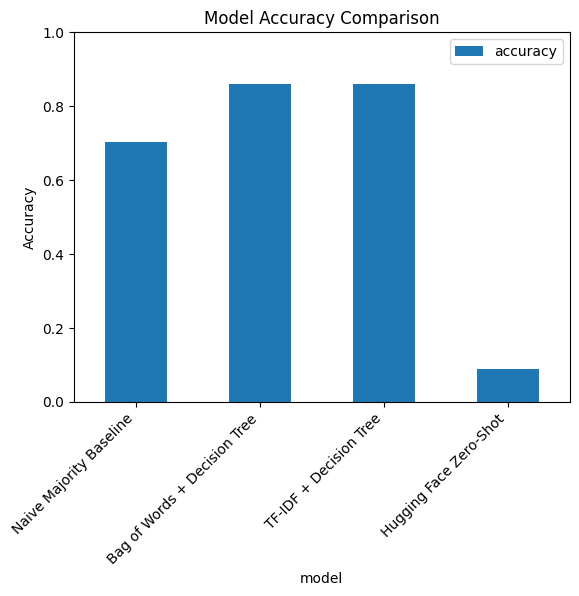

In [72]:
results.plot(x='model', y='accuracy', kind='bar')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.show()

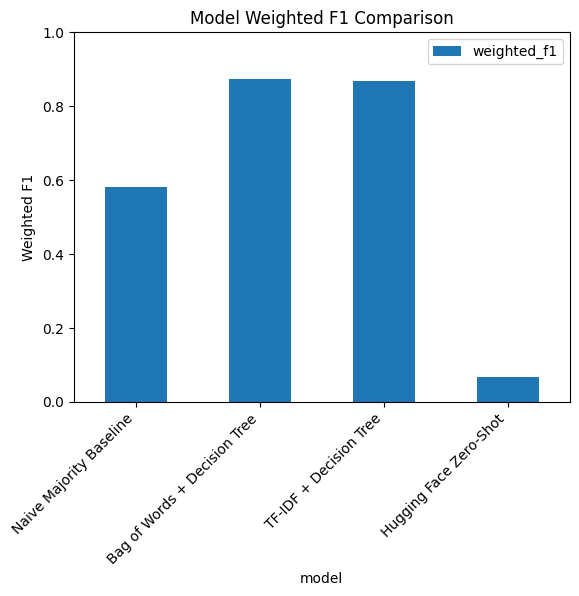

: 

In [ ]:
results.plot(x='model', y='weighted_f1', kind='bar')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.title('Model Weighted F1 Comparison')
plt.ylabel('Weighted F1')
plt.show()

# Discussion

- **class imbalance** : Class II dominates the dataset. -> focus on weighted F1 score + add class_weight='balanced' 

- **text cleaning workflow followed the lecture-note process.** :  I concatenated Product Description and Reason for Recall, then applied lowercase conversion, removed funky characters, removed stop words, tokenized the text, and used Porter stemming. 

- **Bag of Words & TF-IDF models**  : used the Decision Tree Classifier so that i can check if they can beat the naive majority-class prediction.

- **struggled with the stemmed part**:  on the first try, words break down into letters, and i also felt like mos tof the words in this dataset are noun. it might be unneccessary to apply stemming in this case. 


- **zero-shot transformer gives a second benchmark without training a new supervised model.** : only used 100 rows for testing because of runtime issues, but if we had full test dataset, I'm sure that they can get better results. 